In [1]:

from jsonschema import validate
from jsonschema.exceptions import ValidationError
import json

from src.pipeline.ml.context_extractor.utils.helpers.seed_utils import enforce_reproducibility
from src.pipeline.ml.context_extractor.utils.data.data_preprocessor import prepare_data
from src.pipeline.ml.context_extractor.utils.training_pipeline_utils import train_model

import logging

logger = logging.getLogger(__name__)


activity_recognition_config_path = "config/machine-activity-recognition/machine-activity-recognition-config.json"
activity_recognition_config_schema_path = "config/machine-activity-recognition/machine-activity-recognition-config-schema.json"
        
context_extraction_config_path = "config/context-extraction/context-extraction-config.json"
context_extraction_config_schema_path = "config/context-extraction/context-extraction-config-schema.json"

spring_back_config_path = "config/springback-prediction/springback-prediction-config.json"

def get_schema_description(schema_part, path):
    """Traverse schema to find 'description' for a given path."""
    for key in path:
        if 'properties' in schema_part and key in schema_part['properties']:
            schema_part = schema_part['properties'][key]
        else:
            return None
    return schema_part.get('description')

with open(context_extraction_config_path, "r") as f:
    config = json.load(f)
with open(context_extraction_config_schema_path, "r") as f:
    schema = json.load(f)

try:
    validate(instance=config, schema=schema)
    logging.info("Configuration json is valid!")
except ValidationError as e:
    path_list = list(e.path)
    description = get_schema_description(schema, path_list)
    
    if description:
        message = f"Validation failed at '{' -> '.join(str(p) for p in path_list)}': {description}"
    else:
        message = f"Validation failed at '{' -> '.join(str(p) for p in path_list)}': {e.message}"
    
    logging.error(message)


input_path_param = config.get("inputPathParams")
preprocessing_param = config.get("preprocessingParams")
training_params = config.get("trainingParams")
occlusion_params = config.get("occlusionParams")
preprocessing_info = config.get("preprocessingParams")
seed = config.get("generalSetting").get("seed", 42)

process_part = input_path_param.get("process_part")


# ============================================================
# Seeding for reproducibility
# ============================================================
enforce_reproducibility(seed=seed)

# ============================================================
# Read and preprocess data
# ============================================================

(
X_train, Y_train, X_test, Y_test, 
springbacks_train, springbacks_test, 
experiment_configurations_train, experiment_configurations_test, 
sensor_names, target_feature_names, annot_timesteps, 
mandrel_extraction_annot_timesteps) = prepare_data(
input_path_param=input_path_param,
preprocessing_param=preprocessing_param,
)


2026-01-23 16:58:45 | ERROR | <module> | Validation failed at 'trainingParams': Additional properties are not allowed ('feature_loss_types' was unexpected)
2026-01-23 16:58:45 | INFO | wrapper | Entering load_all_data_from_sqlite
2026-01-23 16:58:53 | INFO | wrapper | Finishing load_all_data_from_sqlite


In [2]:
print(f"X_train: {X_train.shape}\nY_train: {Y_train.shape}\nX_test: {X_test.shape}\nY_test: {Y_test.shape}")

X_train: torch.Size([260, 400, 13])
Y_train: torch.Size([260, 15, 2])
X_test: torch.Size([53, 400, 13])
Y_test: torch.Size([53, 15, 2])


In [3]:
import torch
import torch.nn as nn

class ConditionalCNN1D(nn.Module):
    """
    Conditional 1D CNN regressor.
    Predicts targets for a SINGLE angle given its index.

    Inputs:
      x: (B, T, F_in)
      angle_idx: int OR (B,) LongTensor in [0, n_angles-1]
    Outputs:
      y_hat: (B, F_out)
    """
    def __init__(
        self,
        input_features: int,
        n_angles: int,
        output_features: int = 2,
        angle_emb_dim: int = 16,
        channels: int = 128,
        dropout: float = 0.2,
        kernel_size: int = 5,
        pooling: str = "mean",  # "mean" or "max"
    ):
        super().__init__()
        self.n_angles = n_angles
        self.pooling = pooling

        self.angle_emb = nn.Embedding(n_angles, angle_emb_dim)

        # CNN sees channels = input_features + angle_emb_dim
        c_in = input_features + angle_emb_dim
        pad = kernel_size // 2

        self.cnn = nn.Sequential(
            nn.Conv1d(c_in, channels, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Conv1d(channels, channels, kernel_size=kernel_size, padding=pad),
            nn.ReLU(),
        )

        self.head = nn.Sequential(
            nn.LayerNorm(channels),
            nn.Linear(channels, channels // 2),
            nn.ReLU(),
            nn.Linear(channels // 2, output_features),
        )

    def forward(self, x: torch.Tensor, angle_idx: torch.Tensor | int):
        if x.dim() != 3:
            raise ValueError(f"x must be (B,T,F_in); got {tuple(x.shape)}")

        B, T, _ = x.shape

        # Normalize angle_idx to (B,)
        if isinstance(angle_idx, int):
            angle_idx = torch.full((B,), angle_idx, device=x.device, dtype=torch.long)
        else:
            if angle_idx.dim() == 2 and angle_idx.shape[1] == 1:
                angle_idx = angle_idx.squeeze(1)
            if angle_idx.dim() == 0:
                angle_idx = angle_idx.expand(B)
            angle_idx = angle_idx.to(device=x.device, dtype=torch.long)

        a = self.angle_emb(angle_idx)               # (B,E)
        a = a.unsqueeze(1).expand(-1, T, -1)        # (B,T,E)

        x_cond = torch.cat([x, a], dim=-1)          # (B,T,F+E)

        # Conv1d expects (B,C,T)
        z = x_cond.transpose(1, 2)                  # (B, F+E, T)
        z = self.cnn(z)                             # (B, channels, T)

        if self.pooling == "mean":
            h = z.mean(dim=2)                       # (B, channels)
        elif self.pooling == "max":
            h = z.amax(dim=2)                       # (B, channels)
        else:
            raise ValueError("pooling must be 'mean' or 'max'")

        y_hat = self.head(h)                        # (B, output_features)
        return y_hat


/home/arman/Documents/university/Master/Master these 2025/tube-geometry-prediction/tube-venv/lib/python3.11/site-packages/torch/cuda/__init__.py:716: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


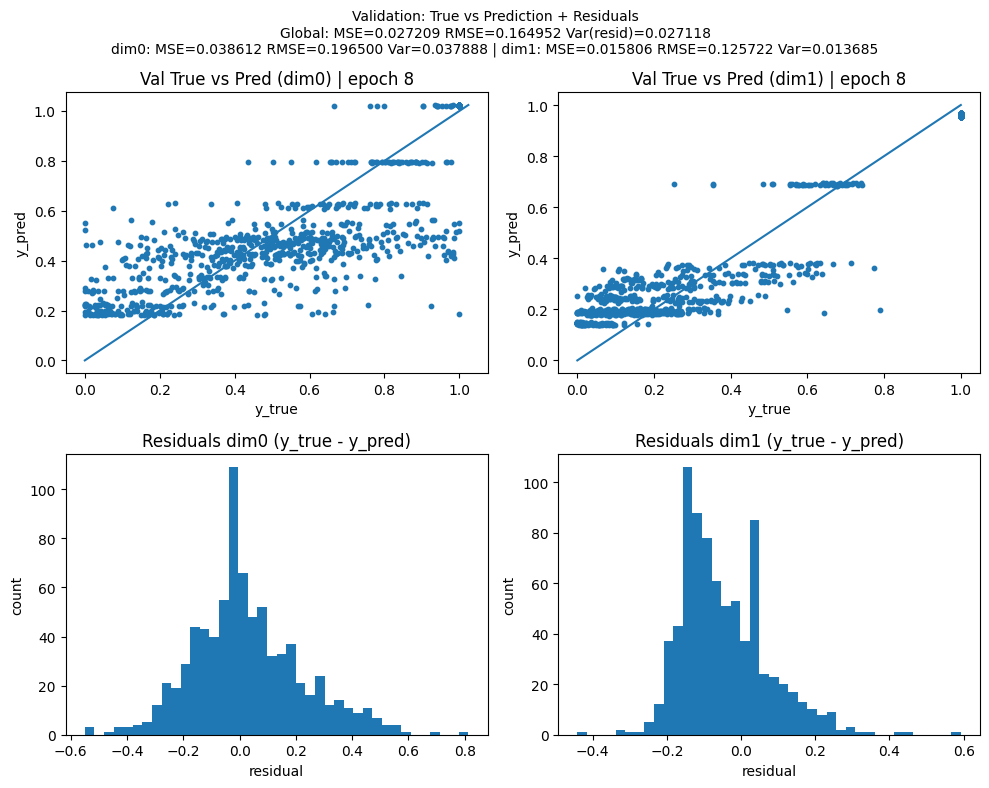

Epochs:   0%|          | 0/60 [00:00<?, ?it/s]

Train 001:   0%|          | 0/61 [00:00<?, ?it/s]

Train 002:   0%|          | 0/61 [00:00<?, ?it/s]

Train 003:   0%|          | 0/61 [00:00<?, ?it/s]

Train 004:   0%|          | 0/61 [00:00<?, ?it/s]

Train 005:   0%|          | 0/61 [00:00<?, ?it/s]

Train 006:   0%|          | 0/61 [00:00<?, ?it/s]

Train 007:   0%|          | 0/61 [00:00<?, ?it/s]

Train 008:   0%|          | 0/61 [00:00<?, ?it/s]

Train 009:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
from IPython.display import display


# -----------------------------
# Your model
# -----------------------------
class ConditionalLSTM(nn.Module):
    def __init__(
        self,
        input_features: int,
        n_angles: int,
        output_features: int = 1,
        hidden_dim: int = 128,
        lstm_layers: int = 2,
        dropout: float = 0.3,
        angle_emb_dim: int = 16,
        pooling: str = "last",
    ):
        super().__init__()
        self.n_angles = n_angles
        self.output_features = output_features
        self.pooling = pooling

        self.angle_emb = nn.Embedding(n_angles, angle_emb_dim)

        self.lstm = nn.LSTM(
            input_size=input_features + angle_emb_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.ln = nn.LayerNorm(hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.ReLU(),
            nn.Linear(hidden_dim // 4, output_features),
        )

    def forward(self, x: torch.Tensor, angle_idx: torch.Tensor | int):
        if x.dim() != 3:
            raise ValueError(f"x must be (B,T,F_in); got {tuple(x.shape)}")

        B, T, _ = x.shape

        if isinstance(angle_idx, int):
            angle_idx = torch.full((B,), angle_idx, device=x.device, dtype=torch.long)
        else:
            if angle_idx.dim() == 2 and angle_idx.shape[1] == 1:
                angle_idx = angle_idx.squeeze(1)
            if angle_idx.dim() == 0:
                angle_idx = angle_idx.expand(B)
            angle_idx = angle_idx.to(device=x.device, dtype=torch.long)

        if angle_idx.shape != (B,):
            raise ValueError(f"angle_idx must be int or (B,); got {tuple(angle_idx.shape)}")

        if angle_idx.min() < 0 or angle_idx.max() >= self.n_angles:
            raise ValueError(f"angle_idx out of range [0, {self.n_angles-1}]")

        a = self.angle_emb(angle_idx)              # (B, E)
        a = a.unsqueeze(1).expand(-1, T, -1)       # (B, T, E)

        x_cond = torch.cat([x, a], dim=-1)         # (B, T, F_in+E)

        o, _ = self.lstm(x_cond)                   # (B, T, H)
        o = self.ln(o)

        if self.pooling == "last":
            h = o[:, -1, :]                        # (B, H)
        elif self.pooling == "mean":
            h = o.mean(dim=1)                      # (B, H)
        else:
            raise ValueError("pooling must be 'last' or 'mean'")

        y_hat = self.head(h)                       # (B, F_out)
        return y_hat


# -----------------------------
# Dataset that unrolls angles
# -----------------------------
class AngleUnrolledDataset(Dataset):
    """
    Turns:
      X: (N, T, F)
      Y: (N, A, O)
    into samples:
      x_i: (T, F)
      angle_idx: scalar long
      y_i: (O,)
    Total length = N * A
    """
    def __init__(self, X: torch.Tensor, Y: torch.Tensor):
        if X.dim() != 3:
            raise ValueError(f"X must be (N,T,F); got {tuple(X.shape)}")
        if Y.dim() != 3:
            raise ValueError(f"Y must be (N,A,O); got {tuple(Y.shape)}")
        if X.shape[0] != Y.shape[0]:
            raise ValueError("X and Y must have same N")
        self.X = X
        self.Y = Y
        self.N = X.shape[0]
        self.A = Y.shape[1]

    def __len__(self):
        return self.N * self.A

    def __getitem__(self, idx):
        n = idx // self.A
        a = idx % self.A
        x = self.X[n]                 # (T,F)
        y = self.Y[n, a]              # (O,)
        angle_idx = torch.tensor(a, dtype=torch.long)
        return x, angle_idx, y


# -----------------------------
# Helpers: collect val preds + update plots (with persistent display)
# -----------------------------
@torch.no_grad()
def collect_predictions(model, loader, device):
    model.eval()
    ys, yhs = [], []
    for x, a, y in loader:
        x = x.to(device, non_blocking=True)
        a = a.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        y_hat = model(x, a)
        ys.append(y.detach().cpu())
        yhs.append(y_hat.detach().cpu())
    return torch.cat(ys, dim=0), torch.cat(yhs, dim=0)  # (N,D), (N,D)


def update_val_plots(fig, axes, y_true, y_pred, epoch: int):
    """
    axes: 2x2
      [0,0] scatter true vs pred dim0
      [0,1] scatter true vs pred dim1
      [1,0] residual hist dim0
      [1,1] residual hist dim1
    """
    y_true = y_true.float()
    y_pred = y_pred.float()
    if y_true.shape[1] != 2:
        raise ValueError("This plotting helper expects 2 output dims (Y last dim = 2).")

    resid = (y_true - y_pred)  # (N,2)

    # Residual variance (population variance)
    var_dim = torch.var(resid, dim=0, unbiased=False)
    var_global = torch.var(resid, unbiased=False).item()

    mse_dim = torch.mean(resid ** 2, dim=0)
    rmse_dim = torch.sqrt(mse_dim)
    mse_global = torch.mean(resid ** 2).item()
    rmse_global = math.sqrt(mse_global)

    # Clear axes and redraw
    for ax in axes.flatten():
        ax.cla()

    # Scatter dim0
    ax = axes[0, 0]
    ax.scatter(y_true[:, 0].numpy(), y_pred[:, 0].numpy(), s=10)
    min0 = min(y_true[:, 0].min().item(), y_pred[:, 0].min().item())
    max0 = max(y_true[:, 0].max().item(), y_pred[:, 0].max().item())
    ax.plot([min0, max0], [min0, max0])
    ax.set_title(f"Val True vs Pred (dim0) | epoch {epoch}")
    ax.set_xlabel("y_true")
    ax.set_ylabel("y_pred")

    # Scatter dim1
    ax = axes[0, 1]
    ax.scatter(y_true[:, 1].numpy(), y_pred[:, 1].numpy(), s=10)
    min1 = min(y_true[:, 1].min().item(), y_pred[:, 1].min().item())
    max1 = max(y_true[:, 1].max().item(), y_pred[:, 1].max().item())
    ax.plot([min1, max1], [min1, max1])
    ax.set_title(f"Val True vs Pred (dim1) | epoch {epoch}")
    ax.set_xlabel("y_true")
    ax.set_ylabel("y_pred")

    # Residual hist dim0
    ax = axes[1, 0]
    ax.hist(resid[:, 0].numpy(), bins=40)
    ax.set_title("Residuals dim0 (y_true - y_pred)")
    ax.set_xlabel("residual")
    ax.set_ylabel("count")

    # Residual hist dim1
    ax = axes[1, 1]
    ax.hist(resid[:, 1].numpy(), bins=40)
    ax.set_title("Residuals dim1 (y_true - y_pred)")
    ax.set_xlabel("residual")
    ax.set_ylabel("count")

    fig.suptitle(
        "Validation: True vs Prediction + Residuals\n"
        f"Global: MSE={mse_global:.6f} RMSE={rmse_global:.6f} Var(resid)={var_global:.6f}\n"
        f"dim0: MSE={mse_dim[0].item():.6f} RMSE={rmse_dim[0].item():.6f} Var={var_dim[0].item():.6f} | "
        f"dim1: MSE={mse_dim[1].item():.6f} RMSE={rmse_dim[1].item():.6f} Var={var_dim[1].item():.6f}",
        fontsize=10
    )
    fig.tight_layout()

    return {
        "mse_global": mse_global,
        "rmse_global": rmse_global,
        "var_resid_global": var_global,
    }


# -----------------------------
# Train loop + tqdm + live-updating plots
# -----------------------------
def train_model(
    X_train, Y_train, X_test, Y_test,
    n_angles=Y_train.shape[1],
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    epochs=60,
    grad_clip=1.0,
    patience=10,
    num_workers=0,
    plot_every=1,   # set to 5 if plotting is slow
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = ConditionalCNN1D(
    input_features=X_train.shape[-1],
    n_angles=n_angles,
    output_features=Y_train.shape[-1],  # 2
    angle_emb_dim=16,
    channels=128,
    dropout=0.2,
    kernel_size=5,
    pooling="mean",
).to(device)


    train_ds = AngleUnrolledDataset(X_train, Y_train)
    test_ds  = AngleUnrolledDataset(X_test,  Y_test)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=(device.type == "cuda")
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=num_workers, pin_memory=(device.type == "cuda")
    )

    loss_fn = nn.MSELoss()
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_loss = math.inf
    best_state = None
    bad_epochs = 0

    # Create ONE figure and a persistent display handle (Notebook-safe updates)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    plot_handle = display(fig, display_id=True)

    epoch_bar = tqdm(range(1, epochs + 1), desc="Epochs", dynamic_ncols=True)

    for epoch in epoch_bar:
        # ---------------------
        # Training
        # ---------------------
        model.train()
        running_loss = 0.0
        seen = 0

        batch_bar = tqdm(train_loader, desc=f"Train {epoch:03d}", leave=False, dynamic_ncols=True)

        for x, a, y in batch_bar:
            x = x.to(device, non_blocking=True)
            a = a.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optim.zero_grad(set_to_none=True)
            y_hat = model(x, a)
            loss = loss_fn(y_hat, y)
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optim.step()

            bs = x.size(0)
            running_loss += loss.item() * bs
            seen += bs

            batch_bar.set_postfix(batch_MSE=f"{loss.item():.5f}")

        train_mse = running_loss / max(1, seen)

        # ---------------------
        # Validation MSE
        # ---------------------
        model.eval()
        val_loss_sum = 0.0
        val_seen = 0

        with torch.no_grad():
            for x, a, y in test_loader:
                x = x.to(device, non_blocking=True)
                a = a.to(device, non_blocking=True)
                y = y.to(device, non_blocking=True)

                y_hat = model(x, a)
                loss = loss_fn(y_hat, y)

                bs = x.size(0)
                val_loss_sum += loss.item() * bs
                val_seen += bs

        val_mse = val_loss_sum / max(1, val_seen)

        # ---------------------
        # Plot true vs pred + residual variance (updates each epoch)
        # ---------------------
        plot_metrics = None
        if plot_every is not None and (epoch % plot_every == 0):
            y_true, y_pred = collect_predictions(model, test_loader, device)
            plot_metrics = update_val_plots(fig, axes, y_true, y_pred, epoch)
            plot_handle.update(fig)  # Key: update same output cell

        # ---------------------
        # tqdm postfix + early stopping
        # ---------------------
        if plot_metrics is None:
            epoch_bar.set_postfix(train_MSE=f"{train_mse:.6f}", val_MSE=f"{val_mse:.6f}")
        else:
            epoch_bar.set_postfix(
                train_MSE=f"{train_mse:.6f}",
                val_MSE=f"{val_mse:.6f}",
                val_RMSE=f"{plot_metrics['rmse_global']:.6f}",
                var_resid=f"{plot_metrics['var_resid_global']:.6f}",
            )

        if val_mse < best_loss - 1e-8:
            best_loss = val_mse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                epoch_bar.write(f"Early stopping at epoch {epoch}, best val MSE = {best_loss:.6f}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model


# -----------------------------
# Example usage (assuming tensors already exist)
# -----------------------------

# -----------------------------
# Simple standardization (train stats) for better optimization
# -----------------------------
# X: (N, T, F)
X_train = X_train.float()
X_test = X_test.float()

x_mean = X_train.mean(dim=(0, 1), keepdim=True)
x_std = X_train.std(dim=(0, 1), keepdim=True)
x_std = torch.where(x_std == 0, torch.ones_like(x_std), x_std)

X_train = (X_train - x_mean) / x_std
X_test = (X_test - x_mean) / x_std

# Y: (N, A, O)
Y_train = Y_train.float()
Y_test = Y_test.float()

y_mean = Y_train.mean(dim=(0, 1), keepdim=True)
y_std = Y_train.std(dim=(0, 1), keepdim=True)
y_std = torch.where(y_std == 0, torch.ones_like(y_std), y_std)

Y_train = (Y_train - y_mean) / y_std
Y_test = (Y_test - y_mean) / y_std
model = train_model(X_train, Y_train, X_test, Y_test, n_angles=Y_train.shape[1], plot_every=1)
